# ИД23-1 Маслов АН ИР (Вариант 6, 26.02.2026)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import files

In [ ]:
uploaded = files.upload()

In [29]:
try:
  df = pd.read_csv(list(uploaded.keys())[0], delimiter = ',', encoding="cp1251")
except:
  df = pd.read_csv('acceptance_tests.csv', delimiter = ',', encoding="cp1251")
df

,test_id,robot_model,parameter,unit,plan_value,actual_value,test_date,tester,status,test_round
0,T001,MA-200,positioning_accuracy,mm,2.0,2.30,2026-02-01,Ivanov,fail,1
1,T002,MA-200,movement_speed,m/s,1.5,1.52,2026-02-01,Ivanov,pass,1
2,T003,MA-200,power_consumption,kW,5.0,4.80,2026-02-01,Ivanov,pass,1
3,T004,MA-200,cycle_time,sec,30.0,32.00,2026-02-01,Petrov,fail,1
4,T005,MA-200,noise_level,dB,75.0,74.00,2026-02-01,Petrov,pass,1
...,...,...,...,...,...,...,...,...,...,...
995,T996,ARC-5,heating_temperature,C,450.0,463.00,2026-08-09,Petrov,fail,1
996,T997,ARC-5,gas_flow,l/min,15.0,14.70,2026-08-09,Petrov,fail,1
997,T998,ARC-5,weld_depth,mm,5.0,5.30,2026-08-09,Sidorov,fail,1
998,T999,PL-100,lifting_capacity,kg,100.0,97.00,2026-08-10,Ivanov,fail,1


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   test_id       1000 non-null   object 
 1   robot_model   1000 non-null   object 
 2   parameter     1000 non-null   object 
 3   unit          1000 non-null   object 
 4   plan_value    1000 non-null   float64
 5   actual_value  1000 non-null   float64
 6   test_date     1000 non-null   object 
 7   tester        1000 non-null   object 
 8   status        1000 non-null   object 
 9   test_round    1000 non-null   int64  
dtypes: float64(2), int64(1), object(7)
memory usage: 78.3+ KB


## Групируем по параметрам

In [31]:
unique_params = df['parameter'].unique()
df_subset = df[df['parameter'].isin(unique_params)].groupby('parameter', sort=False).mean(numeric_only=True).reset_index()
df_subset



,parameter,plan_value,actual_value,test_round
0,positioning_accuracy,2.000000,2.152083,2.437500
1,movement_speed,1.500000,1.514792,2.437500
2,power_consumption,3.775352,3.747887,2.457746
3,cycle_time,30.000000,30.778947,2.452632
4,noise_level,70.052632,69.789474,2.452632
5,max_load,50.000000,50.000000,2.437500
6,welding_accuracy,1.500000,1.629167,2.437500
7,welding_speed,0.800000,0.807500,2.437500
8,heating_temperature,450.000000,456.437500,2.437500
9,gas_flow,15.000000,14.875000,2.437500


## Расчёт отклонения

In [32]:
# Расчет отклонения в процентах
df_subset['deviation_pct'] = ((df_subset['actual_value'] - df_subset['plan_value']) / df_subset['plan_value']) * 100
df_subset

,parameter,plan_value,actual_value,test_round,deviation_pct
0,positioning_accuracy,2.000000,2.152083,2.437500,7.604167
1,movement_speed,1.500000,1.514792,2.437500,0.986111
2,power_consumption,3.775352,3.747887,2.457746,-0.727476
3,cycle_time,30.000000,30.778947,2.452632,2.596491
4,noise_level,70.052632,69.789474,2.452632,-0.375657
5,max_load,50.000000,50.000000,2.437500,0.000000
6,welding_accuracy,1.500000,1.629167,2.437500,8.611111
7,welding_speed,0.800000,0.807500,2.437500,0.937500
8,heating_temperature,450.000000,456.437500,2.437500,1.430556
9,gas_flow,15.000000,14.875000,2.437500,-0.833333


## Визуализация

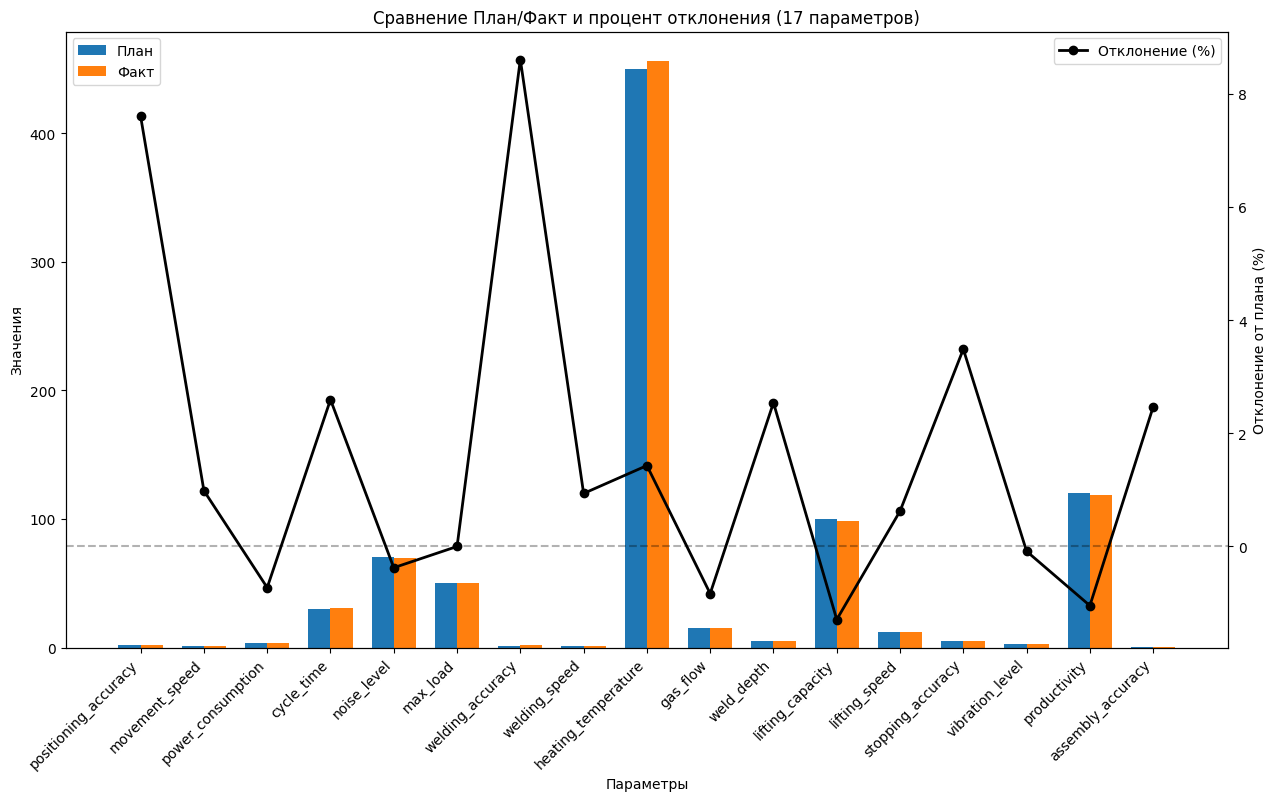

In [33]:

fig, ax1 = plt.subplots(figsize=(15, 8))

x = np.arange(len(df_subset))
width = 0.35

# Столбчатая диаграмма (План/Факт), слева
ax1.bar(x - width/2, df_subset['plan_value'], width, label='План')
ax1.bar(x + width/2, df_subset['actual_value'], width, label='Факт')
ax1.set_xlabel('Параметры')
ax1.set_ylabel('Значения')
ax1.set_title('Сравнение План/Факт и процент отклонения (17 параметров)')
ax1.set_xticks(x)
ax1.set_xticklabels(df_subset['parameter'], rotation=45, ha='right')
ax1.legend(loc='upper left')

# Линейный график (Отклонение), справа
ax2 = ax1.twinx()
ax2.plot(x, df_subset['deviation_pct'], color='black', marker='o', linewidth=2, label='Отклонение (%)')
ax2.axhline(0, color='black', linestyle='--', alpha=0.3) # Линия нулевого отклонения
ax2.set_ylabel('Отклонение от плана (%)')
ax2.legend(loc='upper right')

plt.show()